# EDA Nâng Cao Dữ Liệu Thô - Dự Án SaltySeq

## Tóm tắt
Notebook này phục vụ giai đoạn phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA) trước khi thực hiện feature engineering phức tạp cho bài toán dự báo stress cây trồng do xâm nhập mặn tại Đồng bằng sông Cửu Long.

## Mục tiêu học thuật
1. Đánh giá cấu trúc, chất lượng và tính liên tục theo thời gian của dữ liệu thô.
2. Phân tích chuyên sâu mẫu thiếu dữ liệu của dữ liệu vệ tinh, đặc biệt là NDVI.
3. Khảo sát phân phối, ngoại lệ và đặc trưng thống kê của các biến chính.
4. Kiểm tra mối quan hệ giữa khí tượng - độ mặn - thực vật bằng phân tích tương quan và trực quan chuỗi thời gian.
5. Thực hiện chẩn đoán chuỗi thời gian (ACF/PACF, seasonal decomposition) để biện luận khoa học cho lựa chọn cửa sổ trễ và rolling windows ở bước feature engineering.

In [ ]:
# Cài đặt và import thư viện
import importlib.util
import subprocess
import sys

def ensure_package(package_name: str):
    if importlib.util.find_spec(package_name) is None:
        print(f"Dang cai dat {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "missingno", "statsmodels"]:
    ensure_package(pkg)

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("San sang moi truong phan tich.")

San sang moi truong phan tich.


## 1. Nạp dữ liệu và profiling cơ bản

### Tại sao cần bước này?
Trong bài toán chuỗi thời gian, sai lệch kiểu dữ liệu, lỗi phân tích ngày tháng hoặc chênh lệch schema sẽ làm sai toàn bộ các phân tích phía sau. Vì vậy, cần xác minh data dictionary ngay từ đầu.

### Cần quan sát
- Cột ngày đã được parse đúng và sắp xếp tăng dần theo thời gian.
- Các cột cốt lõi có mặt đầy đủ.
- Giá trị thống kê tổng quát nằm trong miền hợp lý về mặt vật lý.

In [ ]:
# Nap du lieu voi co che fallback
candidate_paths = [
    Path("raw_merged_data.csv"),
    Path("../data/merged_final.csv"),   # notebooks/ -> root/data/
    Path("data/merged_final.csv"),       # neu chay tu project root
    Path("output/merged_final.csv"),     # backward-compat
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Khong tim thay file du lieu. Ky vong: ../data/merged_final.csv")

df_raw = pd.read_csv(data_path)
print(f"Da nap du lieu tu: {data_path.resolve()}")
print(f"Kich thuoc ban dau: {df_raw.shape}")

rename_map = {}
if "soil_moisture" not in df_raw.columns:
    if "soil_moisture_surface" in df_raw.columns:
        rename_map["soil_moisture_surface"] = "soil_moisture"
    elif "soil_moisture_deep" in df_raw.columns:
        rename_map["soil_moisture_deep"] = "soil_moisture"

df = df_raw.rename(columns=rename_map).copy()
required_cols = ["date", "ndvi", "lst", "temp_max", "precipitation", "soil_moisture", "salinity_psu"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Thieu cot bat buoc: {missing_required}")

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# Neu merged_final da noi suy NDVI, tra NDVI ve dung ban chat sparse satelite
if "ndvi_is_observed" in df.columns:
    df["ndvi"] = df["ndvi"].where(df["ndvi_is_observed"] == 1)
    print("Da ap dung mask ndvi_is_observed de phan tich NDVI sparse raw.")

eda_df = df[required_cols].copy()
eda_df.head()

Da nap du lieu tu: D:\SinhVien\UIT_HocChinhKhoa\HK2 2025 - 2026\CS313\DoAN\poc_saltyseq\output\merged_final.csv
Kich thuoc ban dau: (365, 52)
Da ap dung mask ndvi_is_observed de phan tich NDVI sparse raw.


,date,ndvi,lst,temp_max,precipitation,soil_moisture,salinity_psu
0,2023-01-01,0.353714,31.264777,28.6,1.8,0.234667,13.87
1,2023-01-02,NaN,31.264777,31.0,6.2,0.265833,13.20
2,2023-01-03,NaN,31.264777,31.1,2.5,0.261125,11.42
3,2023-01-04,NaN,31.264777,30.5,0.4,0.247083,13.60
4,2023-01-05,NaN,31.264777,26.9,8.9,0.249458,10.45


In [5]:
# Basic profiling
print("Kieu du lieu:")
print(eda_df.dtypes)

print("\nKhoang thoi gian:")
print(f"Bat dau: {eda_df['date'].min()}")
print(f"Ket thuc: {eda_df['date'].max()}")
print(f"Tong so dong: {len(eda_df)}")

print("\nThong ke mo ta:")
display(eda_df.describe(include="all").T)

Kieu du lieu:
date             datetime64[ns]
ndvi                    float64
lst                     float64
temp_max                float64
precipitation           float64
soil_moisture           float64
salinity_psu            float64
dtype: object

Khoang thoi gian:
Bat dau: 2023-01-01 00:00:00
Ket thuc: 2023-12-31 00:00:00
Tong so dong: 365

Thong ke mo ta:


,count,mean,min,25%,50%,75%,max,std
date,365,2023-07-02 00:00:00,2023-01-01 00:00:00,2023-04-02 00:00:00,2023-07-02 00:00:00,2023-10-01 00:00:00,2023-12-31 00:00:00,NaN
ndvi,92.0,0.266098,-0.026538,0.239963,0.284486,0.320871,0.429514,0.089073
lst,365.0,36.270689,27.675842,33.287805,36.733332,39.10331,45.656963,3.635579
temp_max,365.0,31.243562,25.6,30.5,31.2,32.1,36.5,1.665237
precipitation,365.0,6.511507,0.0,0.2,3.1,10.1,75.2,8.534631
soil_moisture,365.0,0.3179,0.148375,0.205167,0.375458,0.408833,0.429292,0.101847
salinity_psu,365.0,11.672411,0.5,2.21,10.94,19.95,28.95,9.182145


## 2. Phân tích missing values, trọng tâm là dữ liệu vệ tinh

### Tại sao cần bước này?
NDVI/LST được lấy từ vệ tinh nên có tính chất gián đoạn theo chu kỳ chụp và mức độ che phủ mây. Trong khi đó, dữ liệu thời tiết theo ngày thường đầy đủ hơn. Phân tích missing values giúp đánh giá mức độ rủi ro khi nội suy.

### Cần quan sát
- Mẫu thiếu có cấu trúc theo thời gian của NDVI.
- So sánh độ đầy đủ của NDVI với weather/salinity.
- Độ dài các đoạn thiếu liên tiếp (gap length).

<Figure size 1600x500 with 0 Axes>

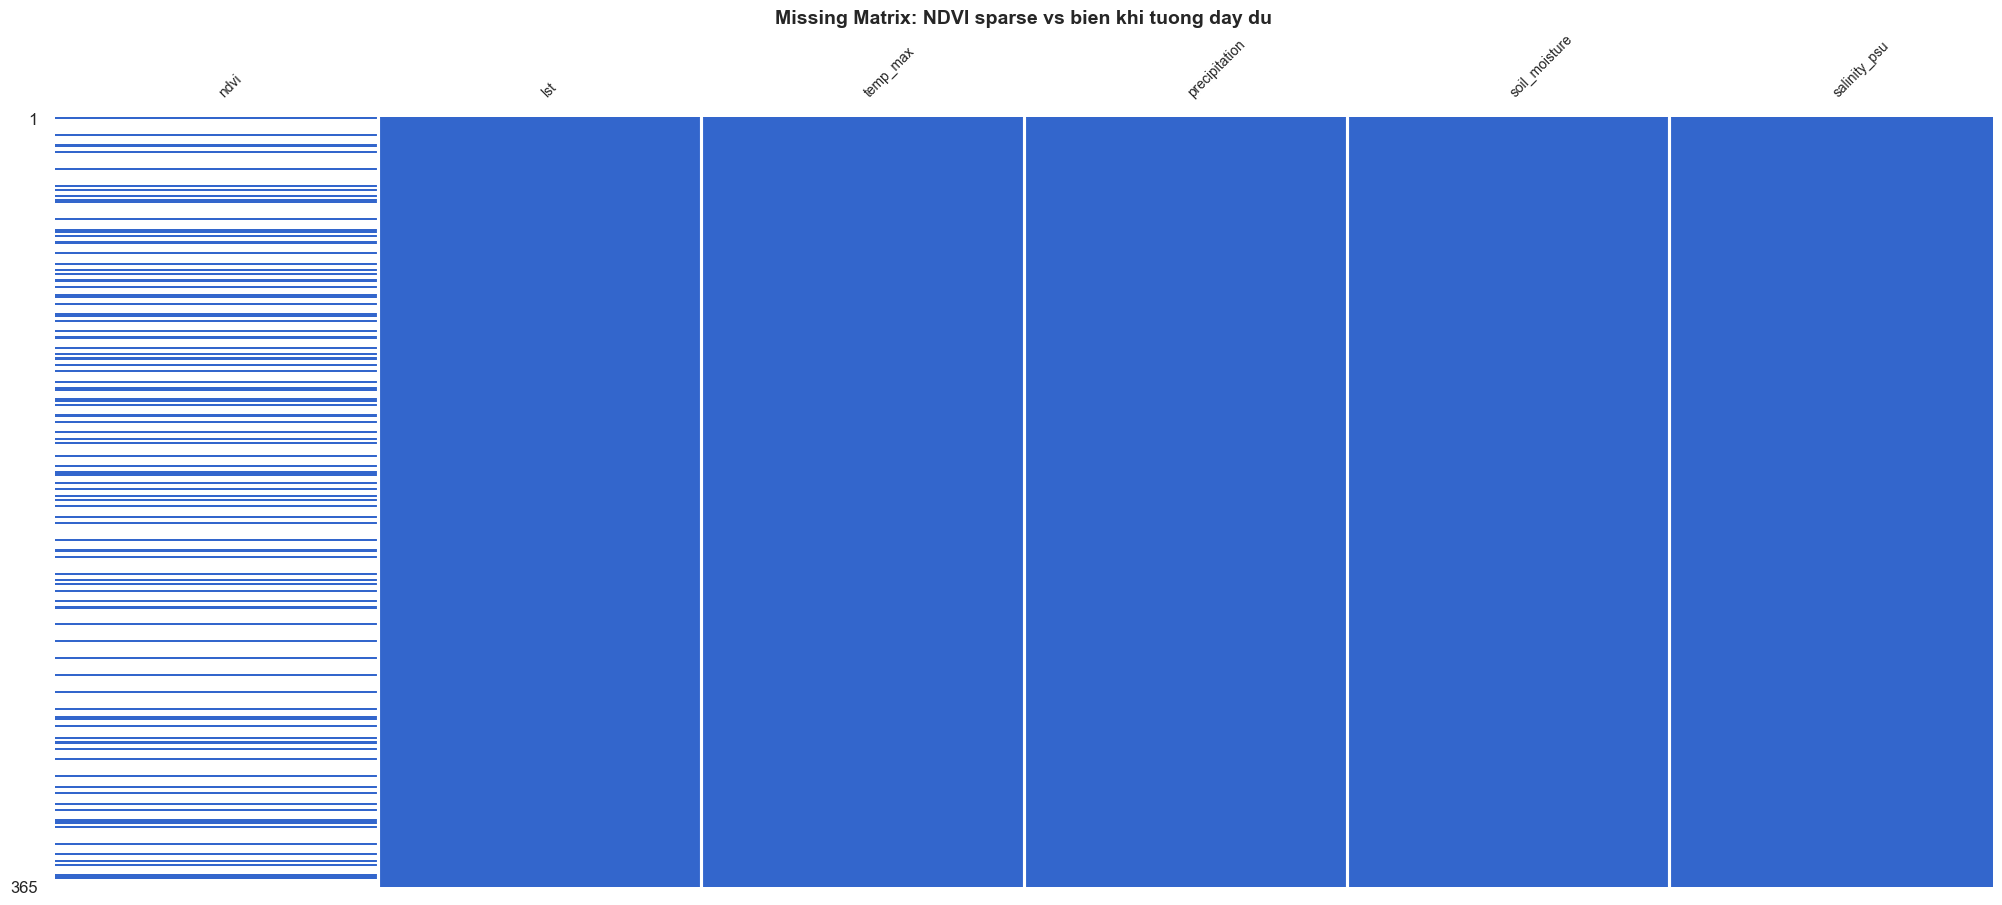

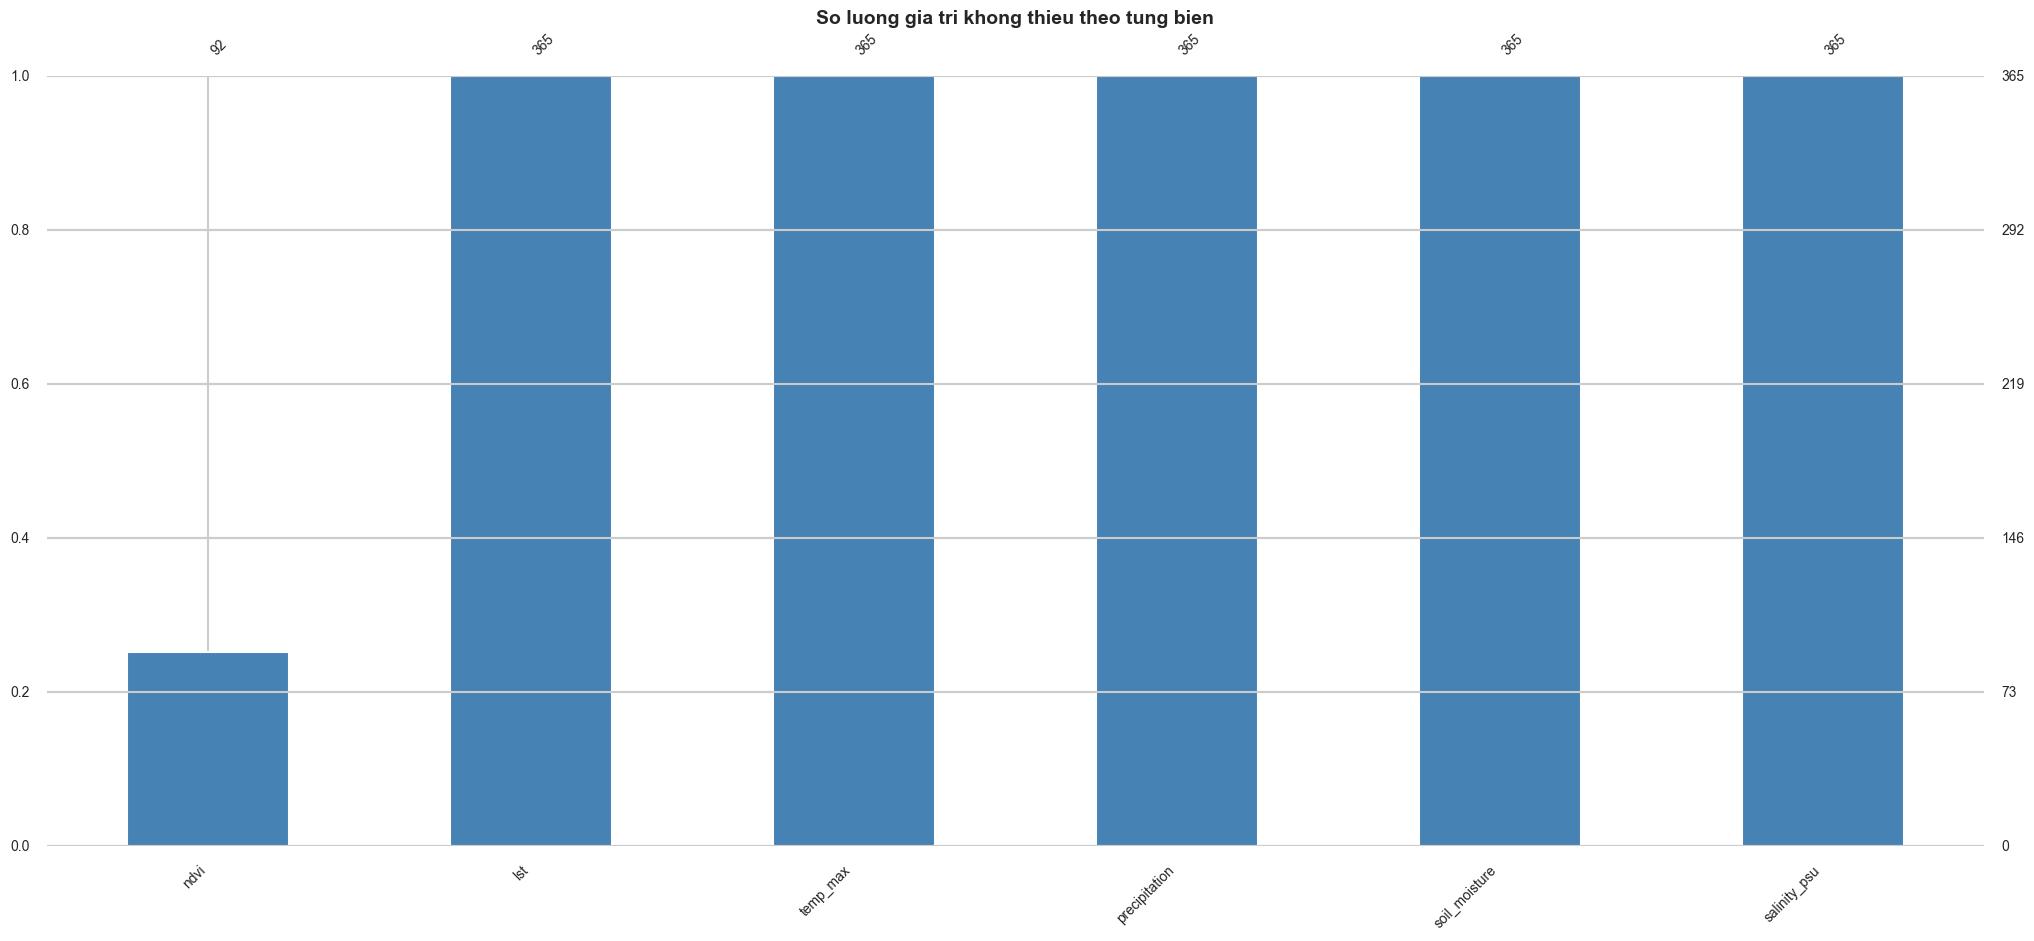

In [ ]:
# Missing matrix + missing bar
missing_view = eda_df.set_index("date")

plt.figure(figsize=(16, 5))
msno.matrix(missing_view, sparkline=False, fontsize=10, color=(0.2, 0.4, 0.8))
plt.title("Missing Matrix: NDVI sparse vs bien khi tuong day du")
plt.show()

plt.figure(figsize=(12, 4))
msno.bar(missing_view, color="steelblue", fontsize=10)
plt.title("So luong gia tri khong thieu theo tung bien")
plt.show()

,missing_percent
ndvi,74.79
date,0.00
lst,0.00
temp_max,0.00
precipitation,0.00
soil_moisture,0.00
salinity_psu,0.00


So doan gap NDVI: 82
Gap lon nhat: 7 ngay
Gap trung vi: 2.5 ngay


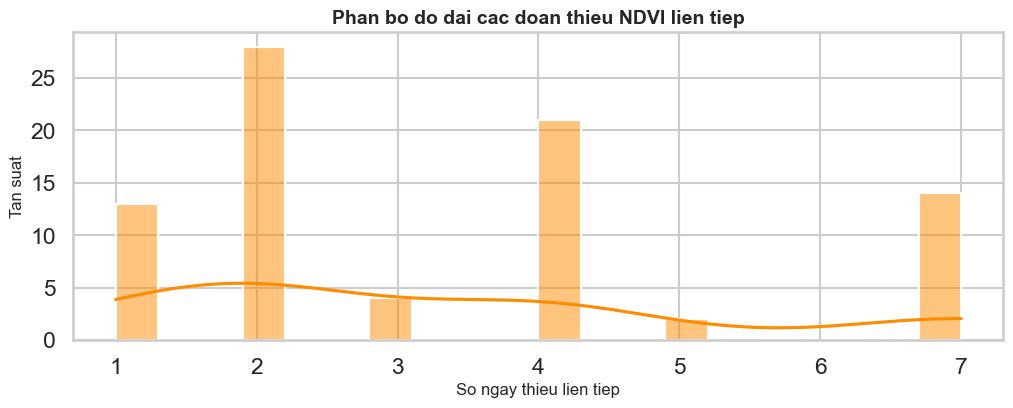

In [ ]:
# Dinh luong missingness va gap NDVI
missing_pct = (eda_df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame(name="missing_percent"))

ndvi_missing = eda_df["ndvi"].isna()
group_id = (ndvi_missing != ndvi_missing.shift()).cumsum()
gap_lengths = ndvi_missing.groupby(group_id).sum()
gap_lengths = gap_lengths[gap_lengths > 0]

if len(gap_lengths) > 0:
    print(f"So doan gap NDVI: {len(gap_lengths)}")
    print(f"Gap lon nhat: {int(gap_lengths.max())} ngay")
    print(f"Gap trung vi: {float(gap_lengths.median()):.1f} ngay")
else:
    print("Khong co gap NDVI.")

plt.figure(figsize=(12, 4))
if len(gap_lengths) > 0:
    sns.histplot(gap_lengths, bins=min(20, len(gap_lengths)), kde=True, color="darkorange")
    plt.title("Phan bo do dai cac doan thieu NDVI lien tiep")
    plt.xlabel("So ngay thieu lien tiep")
    plt.ylabel("Tan suat")
else:
    plt.text(0.5, 0.5, "Khong co gap NDVI", ha="center", va="center")
    plt.axis("off")
plt.show()

## 3. Univariate Analysis: phân phối và ngoại lệ

### Tại sao cần bước này?
Mục tiêu là nhận diện skewness, heavy-tail và các giá trị cực trị để đánh giá tính ổn định của dữ liệu đầu vào. Boxplot giúp nhìn nhanh các sự kiện bất thường như đỉnh độ mặn, mưa lớn bất thường hoặc đợt nóng.

### Cần quan sát
- Dạng phân phối của NDVI, salinity, precipitation và temp_max.
- Mức độ lệch phải (right skew) của precipitation.
- Ngoại lệ có ý nghĩa vật lý hay là lỗi đo lường.

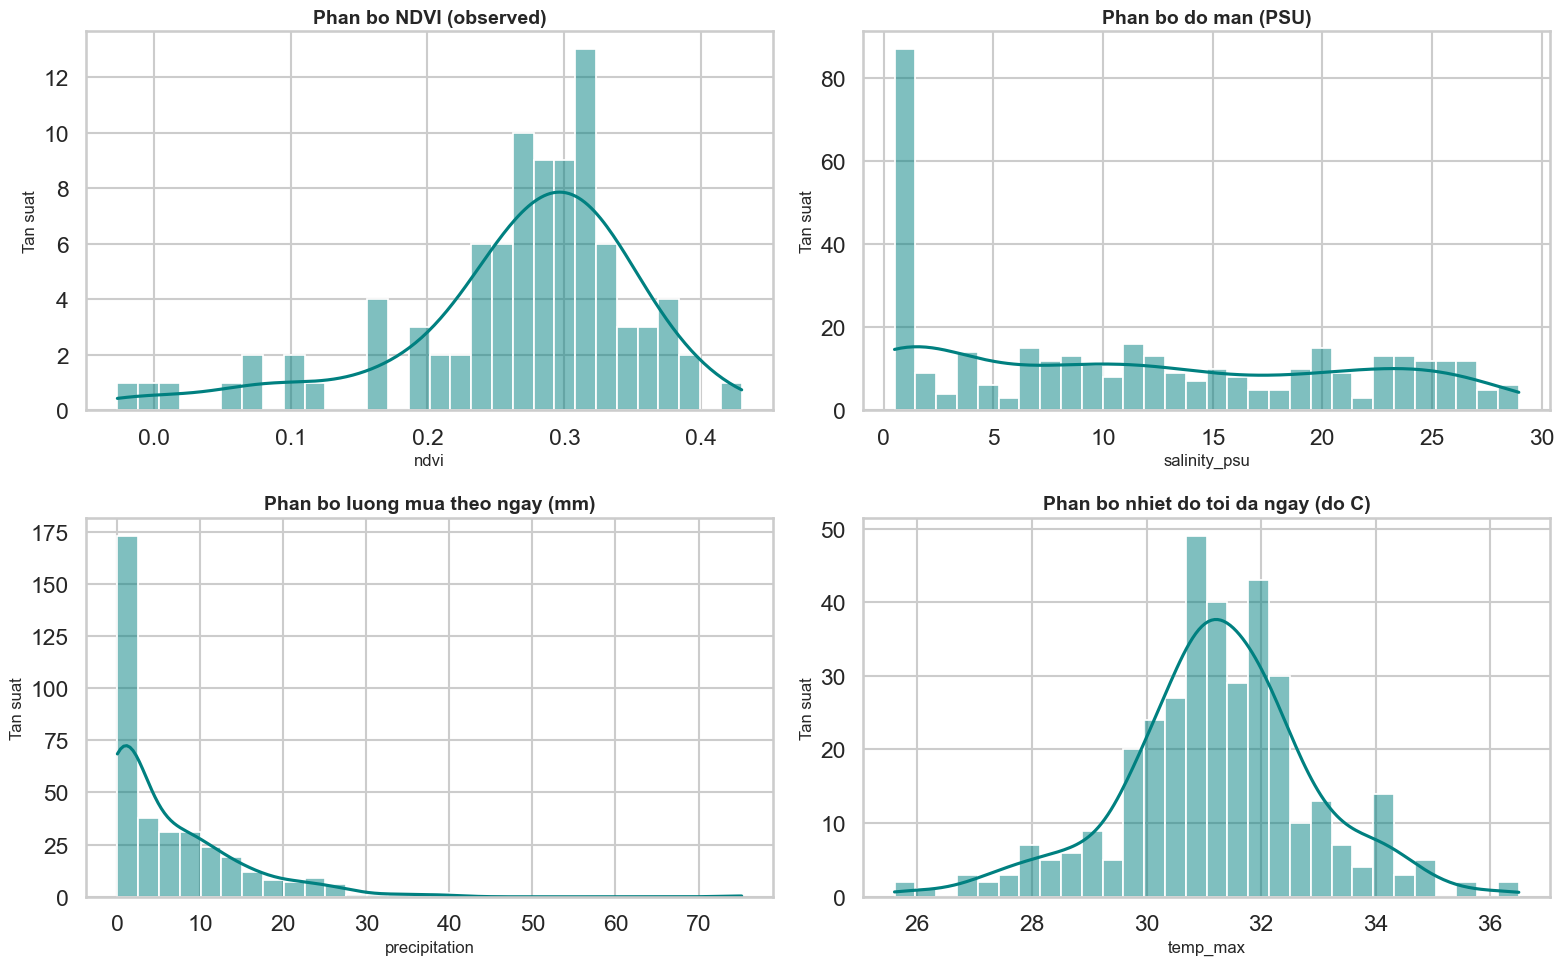

In [ ]:
# Histogram + KDE
plot_vars = ["ndvi", "salinity_psu", "precipitation", "temp_max"]
plot_titles = {
    "ndvi": "Phan bo NDVI (observed)",
    "salinity_psu": "Phan bo do man (PSU)",
    "precipitation": "Phan bo luong mua theo ngay (mm)",
    "temp_max": "Phan bo nhiet do toi da ngay (do C)"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, var in zip(axes, plot_vars):
    sns.histplot(eda_df[var].dropna(), kde=True, bins=30, ax=ax, color="teal")
    ax.set_title(plot_titles[var])
    ax.set_xlabel(var)
    ax.set_ylabel("Tan suat")

plt.tight_layout()
plt.show()

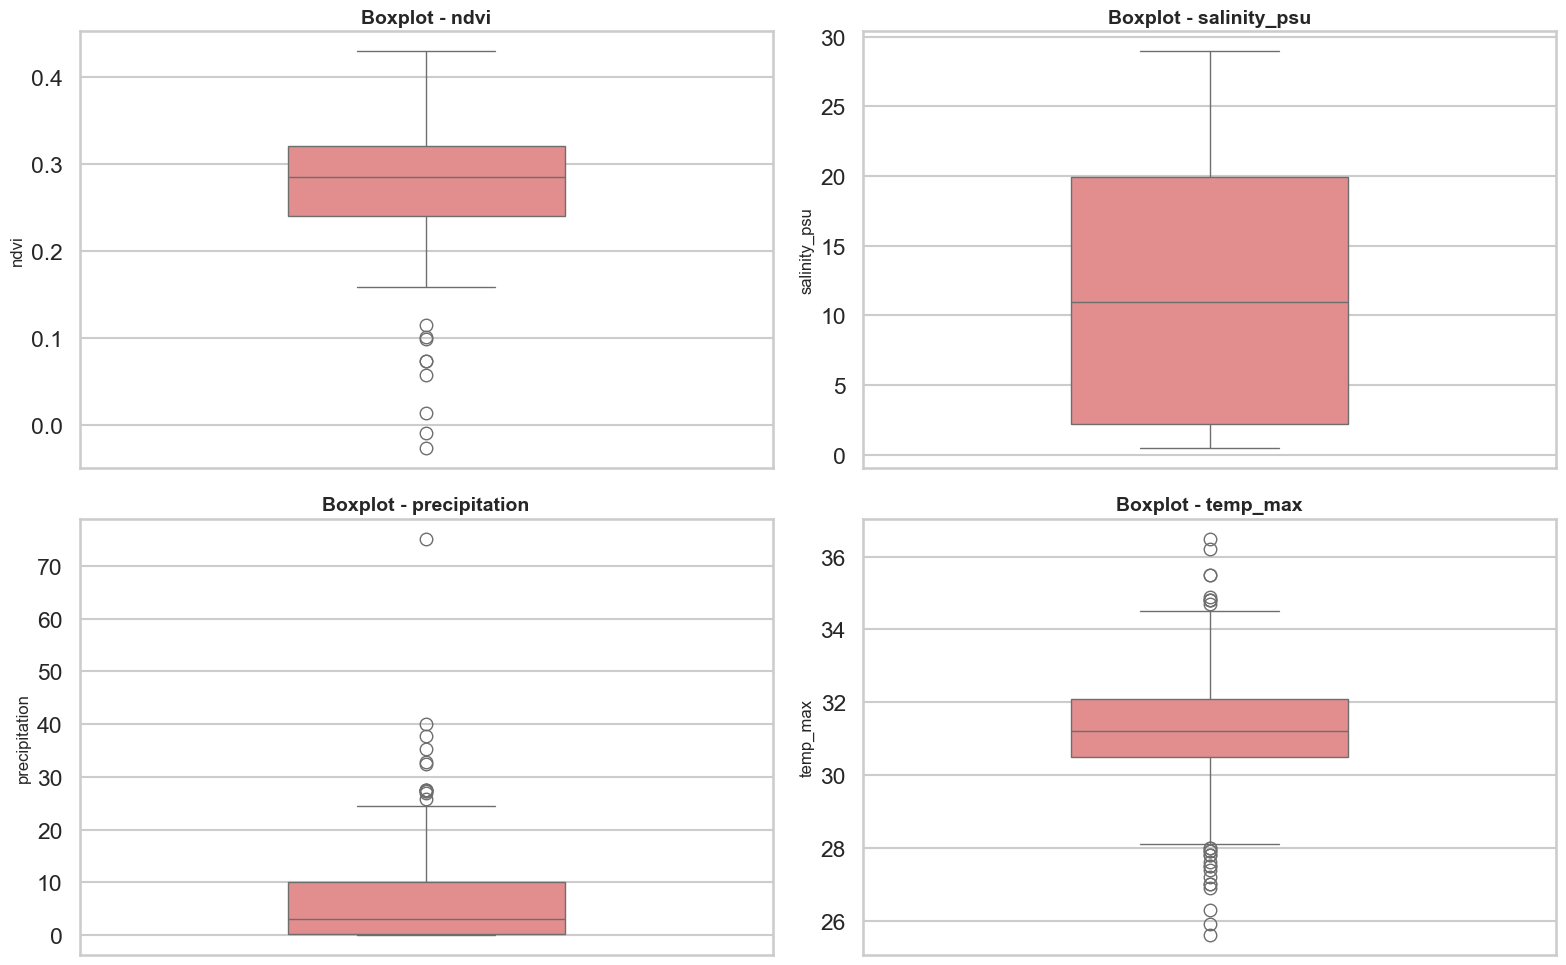

In [ ]:
# Boxplot de phat hien outlier
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, var in zip(axes, plot_vars):
    sns.boxplot(y=eda_df[var], ax=ax, color="lightcoral", width=0.4)
    ax.set_title(f"Boxplot - {var}")
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

## 4. Phân tích hai biến và đa biến

### Tại sao cần bước này?
Bước này giúp nhận diện các mối liên hệ thống kê giữa biến khí tượng, độ mặn và chỉ số thực vật. Kết quả sẽ là cơ sở để chọn feature ưu tiên cho mô hình ML và đặt giả thuyết về hiệu ứng trễ.

### Cần quan sát
- Biến nào có tương quan mạnh với salinity và NDVI.
- Có hiện tượng salinity tăng rồi NDVI giảm theo sau hay không.
- Mức độ đồng biến hoặc nghịch biến giữa độ ẩm đất và độ mặn.

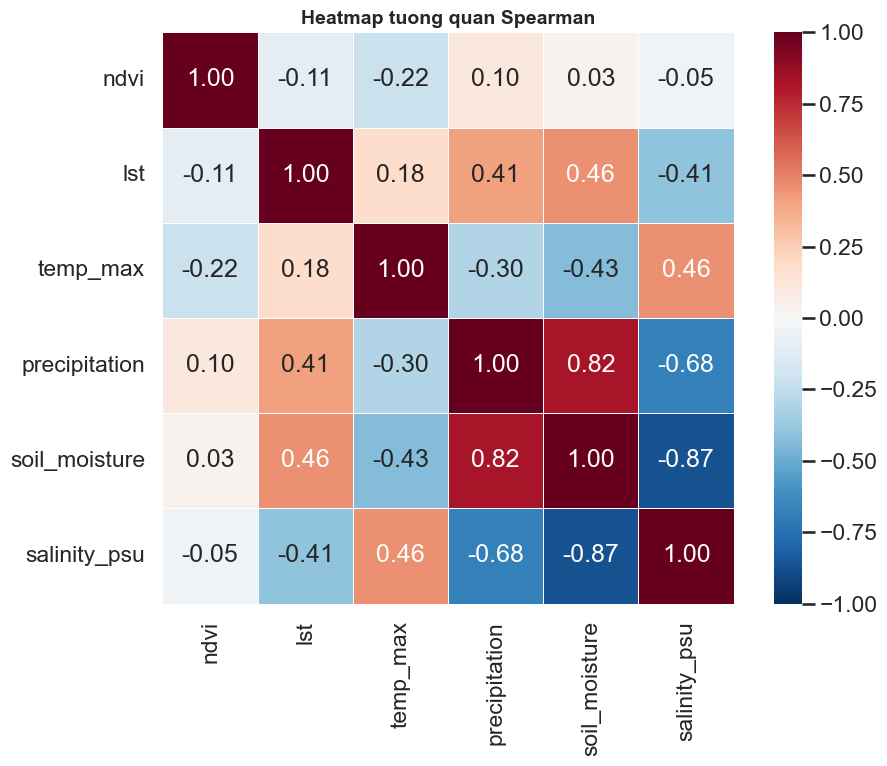

In [ ]:
#Heatmap tuong quan Spearman
corr_vars = ["ndvi", "lst", "temp_max", "precipitation", "soil_moisture", "salinity_psu"]
corr_df = eda_df[corr_vars].copy()
corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Heatmap tuong quan Spearman")
plt.tight_layout()
plt.show()

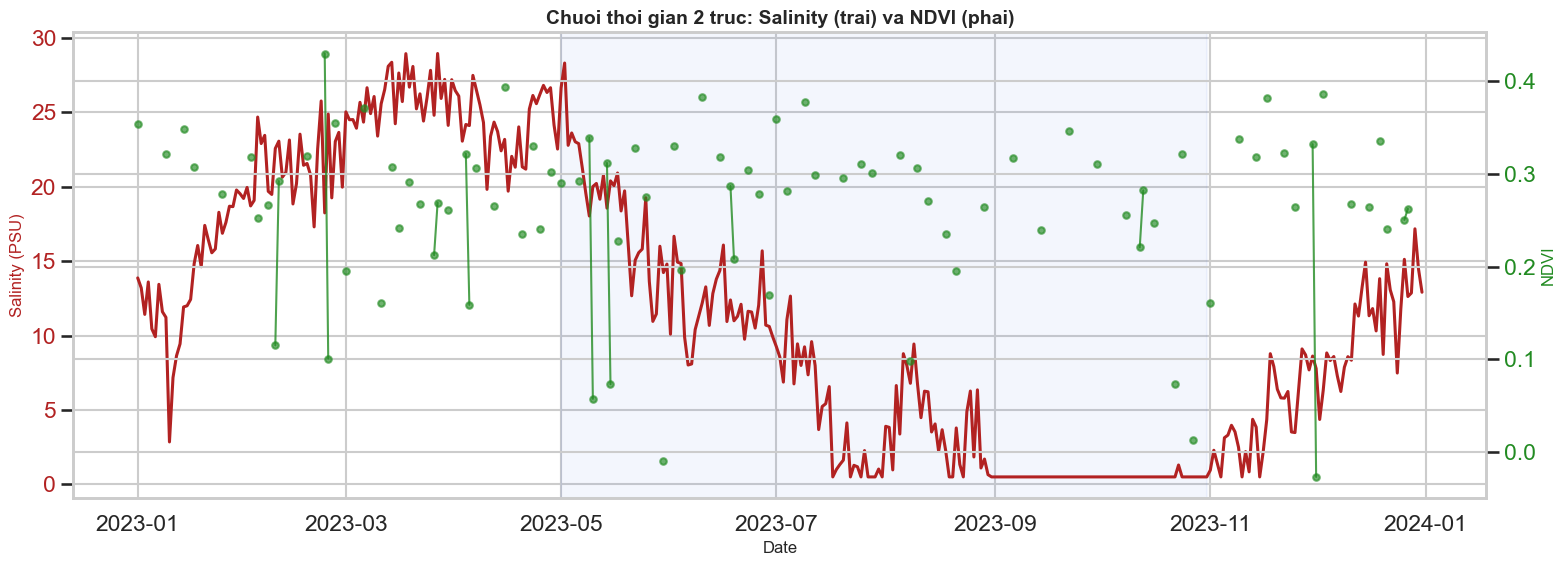

In [ ]:
# Dual-axis line chart (salinity vs NDVI theo thoi gian)
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(eda_df["date"], eda_df["salinity_psu"], color="firebrick", linewidth=2.2, label="Salinity (PSU)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Salinity (PSU)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")

ax2 = ax1.twinx()
ax2.plot(eda_df["date"], eda_df["ndvi"], color="forestgreen", linewidth=1.5, alpha=0.8, label="NDVI")
ax2.scatter(eda_df["date"], eda_df["ndvi"], color="forestgreen", s=22, alpha=0.65)
ax2.set_ylabel("NDVI", color="forestgreen")
ax2.tick_params(axis="y", labelcolor="forestgreen")

years = sorted(eda_df["date"].dt.year.dropna().unique())
for y in years:
    wet_start = pd.Timestamp(year=int(y), month=5, day=1)
    wet_end = pd.Timestamp(year=int(y), month=10, day=31)
    ax1.axvspan(wet_start, wet_end, color="royalblue", alpha=0.06)

plt.title("Chuoi thoi gian 2 truc: Salinity (trai) va NDVI (phai)")
fig.tight_layout()
plt.show()

## 5. Time-Series EDA, điểm nhấn học thuật

### Tại sao cần bước này?
ACF/PACF giúp đánh giá cấu trúc ghi nhớ của chuỗi và hỗ trợ lựa chọn lag features có cơ sở thống kê. Seasonal decomposition cho thấy thành phần xu hướng, mùa vụ và nhiễu, từ đó giúp biện luận mối liên hệ giữa mùa khô và mùa mưa.

### Cần quan sát
- Salinity và NDVI có trí nhớ ngắn hạn hay dài hạn.
- Lag nào nổi bật để đưa vào feature engineering.
- Thành phần mùa vụ có mạnh hay không.

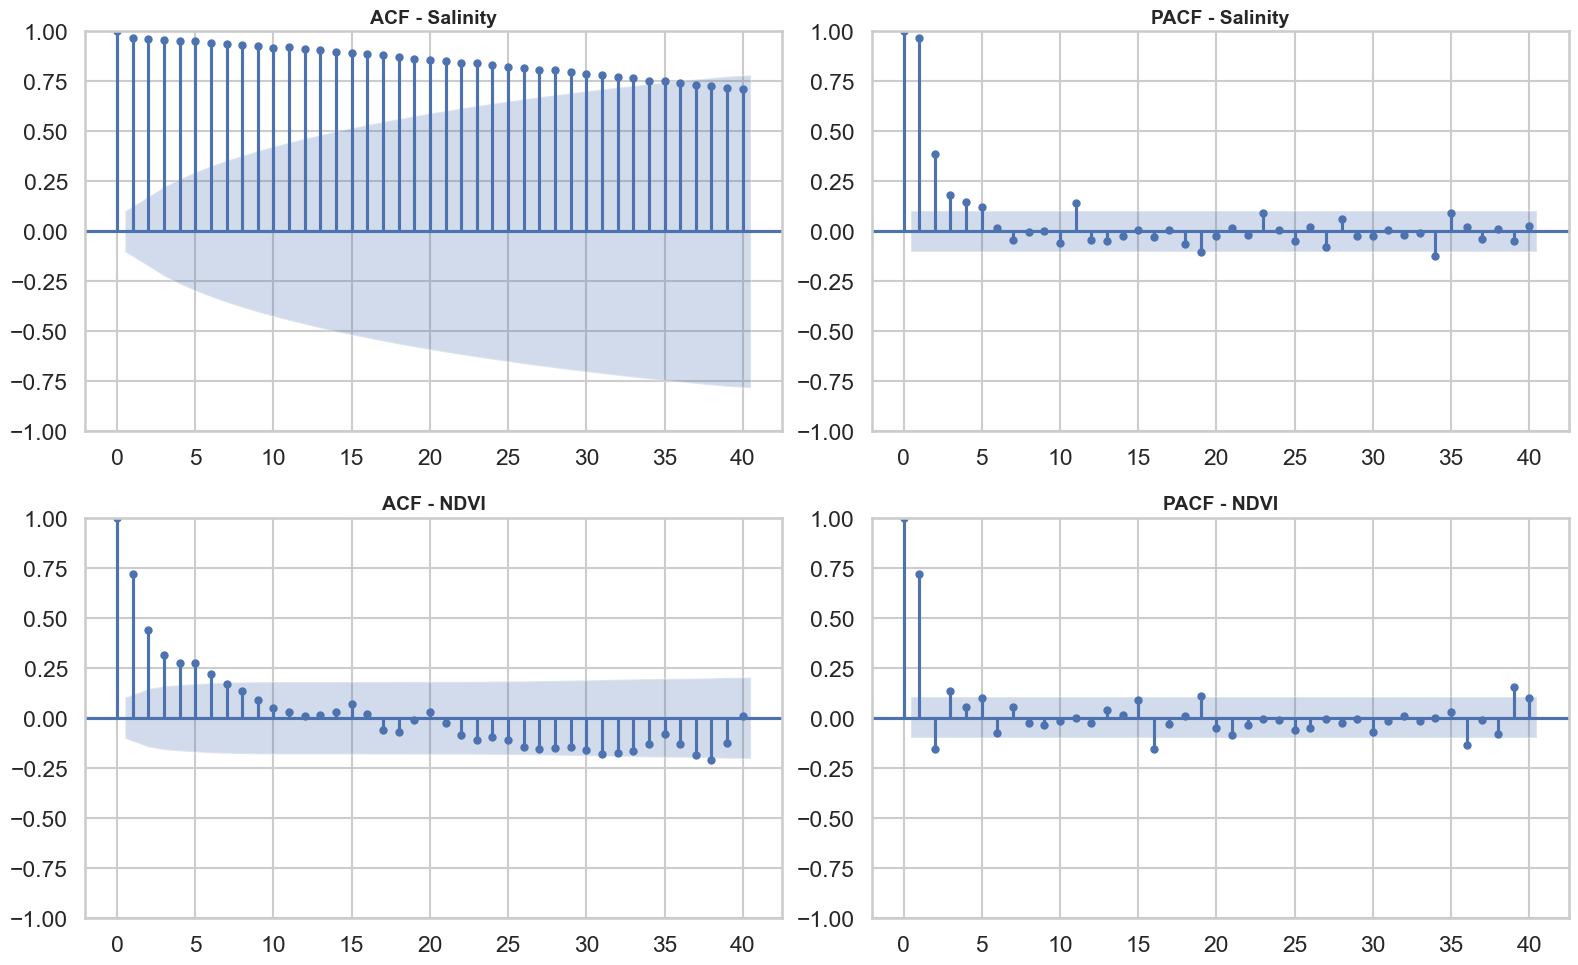

Top lag autocorrelation (Salinity):
lag= 1, autocorr= 0.969
lag= 2, autocorr= 0.962
lag= 3, autocorr= 0.956
lag= 4, autocorr= 0.953
lag= 5, autocorr= 0.951
lag= 6, autocorr= 0.945
lag= 7, autocorr= 0.937
lag= 8, autocorr= 0.932

Top lag autocorrelation (NDVI):
lag= 1, autocorr= 0.718
lag= 2, autocorr= 0.439
lag= 3, autocorr= 0.316
lag= 5, autocorr= 0.275
lag= 4, autocorr= 0.274
lag= 6, autocorr= 0.218
lag= 7, autocorr= 0.173
lag=30, autocorr=-0.166


In [ ]:
# ACF/PACF cho salinity va NDVI
ts = eda_df.set_index("date").sort_index().asfreq("D")

salinity_ts = ts["salinity_psu"].interpolate(method="time").ffill().bfill()
ndvi_ts = ts["ndvi"].interpolate(method="time", limit=15).ffill().bfill()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_acf(salinity_ts, lags=40, ax=axes[0, 0], title="ACF - Salinity")
plot_pacf(salinity_ts, lags=40, ax=axes[0, 1], method="ywm", title="PACF - Salinity")
plot_acf(ndvi_ts, lags=40, ax=axes[1, 0], title="ACF - NDVI")
plot_pacf(ndvi_ts, lags=40, ax=axes[1, 1], method="ywm", title="PACF - NDVI")
plt.tight_layout()
plt.show()

def top_autocorr_lags(series, max_lag=30, top_n=8):
    vals = []
    for lag in range(1, max_lag + 1):
        vals.append((lag, series.autocorr(lag=lag)))
    vals = sorted(vals, key=lambda x: abs(x[1]), reverse=True)
    return vals[:top_n]

print("Top lag autocorrelation (Salinity):")
for lag, val in top_autocorr_lags(salinity_ts, max_lag=30, top_n=8):
    print(f"lag={lag:2d}, autocorr={val: .3f}")

print("\nTop lag autocorrelation (NDVI):")
for lag, val in top_autocorr_lags(ndvi_ts, max_lag=30, top_n=8):
    print(f"lag={lag:2d}, autocorr={val: .3f}")

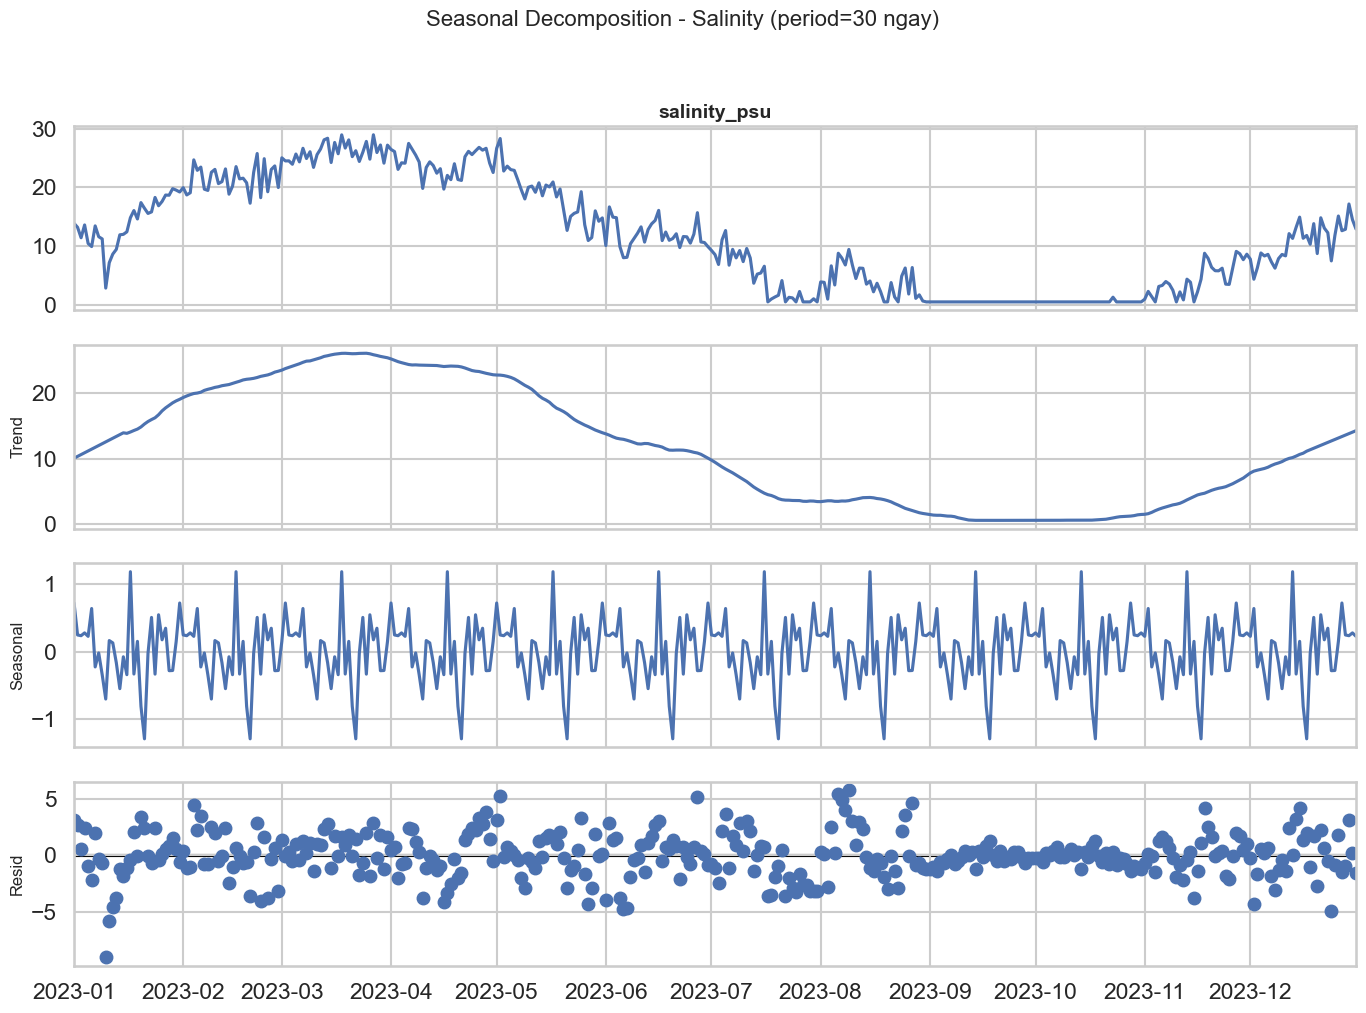

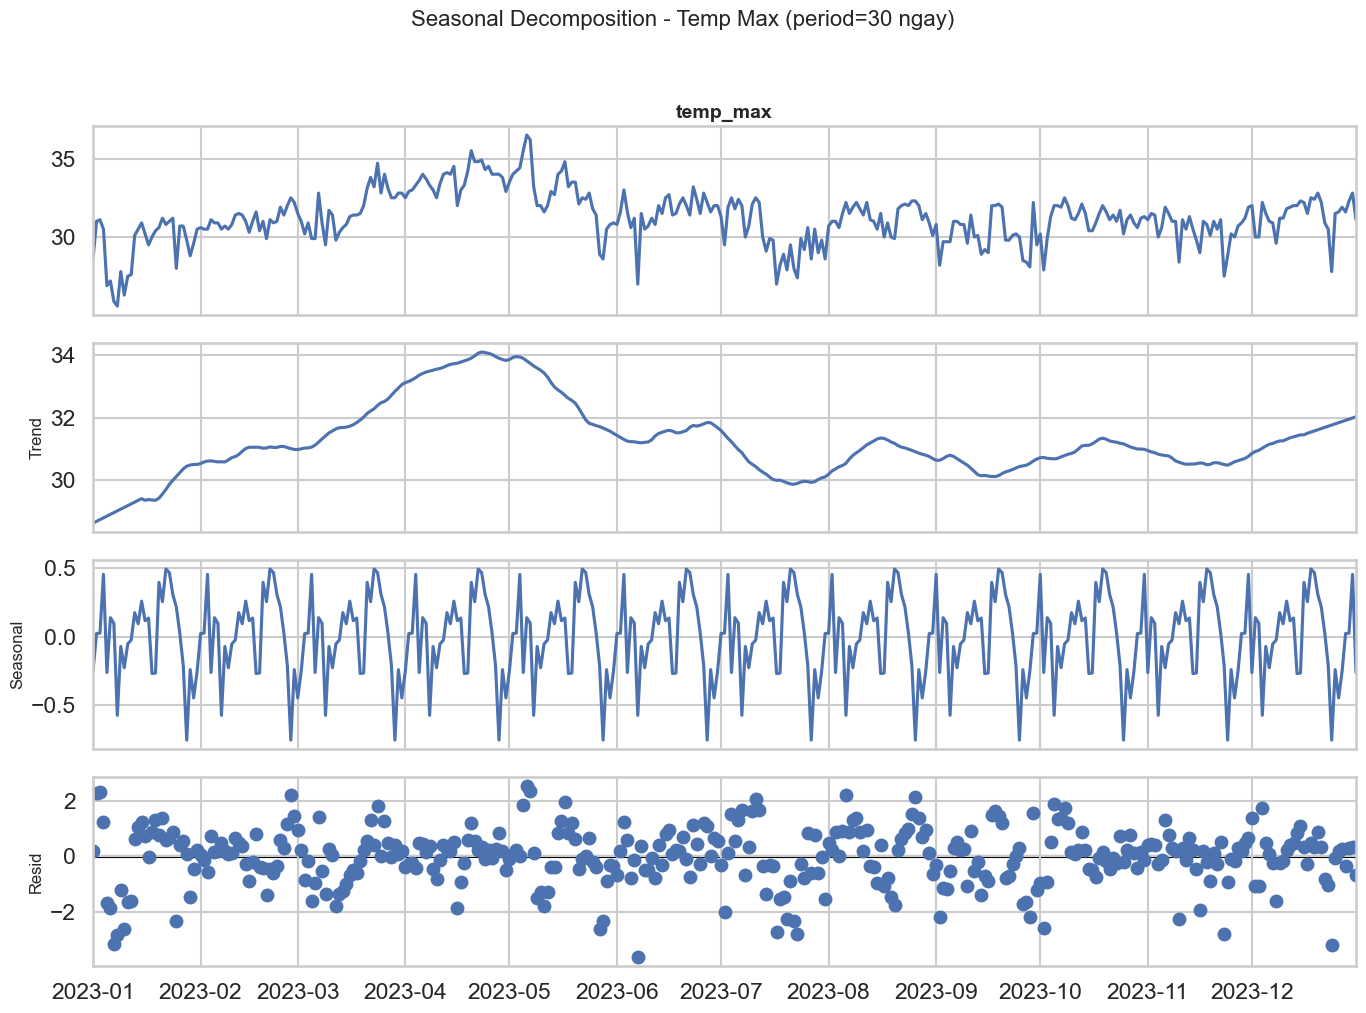

In [ ]:
# Seasonal decomposition
salinity_decomp = seasonal_decompose(salinity_ts, model="additive", period=30, extrapolate_trend="freq")
temp_ts = ts["temp_max"].interpolate(method="time").ffill().bfill()
temp_decomp = seasonal_decompose(temp_ts, model="additive", period=30, extrapolate_trend="freq")

fig1 = salinity_decomp.plot()
fig1.set_size_inches(14, 10)
fig1.suptitle("Seasonal Decomposition - Salinity (period=30 ngay)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

fig2 = temp_decomp.plot()
fig2.set_size_inches(14, 10)
fig2.suptitle("Seasonal Decomposition - Temp Max (period=30 ngay)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Tổng hợp nhận định để đưa vào báo cáo capstone

Sau khi chạy toàn bộ notebook, có thể viết kết luận theo khung sau:

1. **Missingness**
   - NDVI thiếu bao nhiêu phần trăm? Gap lớn nhất là bao nhiêu ngày?
   - Có cần giới hạn nội suy theo ngưỡng, ví dụ 15 ngày, hay không?

2. **Distribution và outlier**
   - Các cực trị của salinity, mưa và nhiệt độ có ý nghĩa vật lý không?
   - Có sự kiện nào cần đánh dấu là anomaly ở giai đoạn feature engineering không?

3. **Relationship**
   - Salinity tăng có đi kèm với NDVI giảm, có thể có độ trễ, hay không?

4. **Time-series memory**
   - ACF/PACF có ủng hộ việc dùng lag 7 ngày hoặc rolling 7 ngày hay không?

5. **Seasonality**
   - Decomposition có tách được xu hướng theo mùa khô và mùa mưa hay không?

Hoàn tất 5 mục trên sẽ tạo cơ sở khoa học vững chắc để chuyển sang bước feature engineering và mô hình hóa ML.